# 실습 2. 매출 데이터 분석 프로토콜
목표: 데이터 점검 → KPI 계산 → 차트 → 검증 → 보고서 초안 생성 흐름을 익힙니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
DATA_DIR = Path('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/data')
OUTPUT_DIR = Path('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/output')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
sales_path = DATA_DIR / 'sample_sales.csv'
df = pd.read_csv(sales_path)
df.head()

,date,region,sales_rep,product_group,customer_type,quantity,revenue,target_revenue,cost
0,2026-01-01,호남,담당자04,Premium TV,B2C,4.0,4520121.0,5117193.0,2640279
1,2026-01-02,수도권,담당자09,Premium TV,B2B,4.0,3934899.0,3188867.0,2622173
2,2026-01-03,수도권,담당자04,AI 가전,B2C,8.0,7623654.0,8289259.0,4492543
3,2026-01-04,수도권,담당자12,노트북,B2B,3.0,3261569.0,3277866.0,2338044
4,2026-01-05,호남,담당자10,노트북,B2C,2.0,2292702.0,2491529.0,1633560


## 2-1. 데이터 구조 점검

In [4]:
print('shape:', df.shape)
display(df.dtypes.to_frame('dtype'))
display(df.isna().sum().to_frame('missing_count'))
print('duplicate rows:', df.duplicated().sum())

shape: (182, 9)


,dtype
date,object
region,object
sales_rep,object
product_group,object
customer_type,object
quantity,float64
revenue,float64
target_revenue,float64
cost,int64


,missing_count
date,0
region,1
sales_rep,0
product_group,0
customer_type,0
quantity,1
revenue,1
target_revenue,1
cost,0


duplicate rows: 2


## 2-2. 전처리 원칙 정하기
결측치와 중복을 바로 처리하지 말고, 어떤 방식이 적절한지 먼저 설명합니다.

In [5]:
issues = {
    'rows': len(df),
    'missing_cells': int(df.isna().sum().sum()),
    'duplicate_rows': int(df.duplicated().sum()),
    'date_min': df['date'].min(),
    'date_max': df['date'].max(),
}
issues

{'rows': 182,
 'missing_cells': 4,
 'duplicate_rows': 2,
 'date_min': '2026-01-01',
 'date_max': '2026-06-29'}

## 2-3. 분석용 데이터 만들기

In [6]:
clean = df.drop_duplicates().copy()
clean['date'] = pd.to_datetime(clean['date'])
# 핵심 KPI 계산에 필요한 수치 결측은 제외하고 집계합니다.
for col in ['quantity','revenue','target_revenue','cost']:
    clean[col] = pd.to_numeric(clean[col], errors='coerce')
clean['month'] = clean['date'].dt.to_period('M').astype(str)
clean['profit'] = clean['revenue'] - clean['cost']
clean['achievement_rate'] = clean['revenue'] / clean['target_revenue']
clean.head()

,date,region,sales_rep,product_group,customer_type,quantity,revenue,target_revenue,cost,month,profit,achievement_rate
0,2026-01-01,호남,담당자04,Premium TV,B2C,4.0,4520121.0,5117193.0,2640279,2026-01,1879842.0,0.883320
1,2026-01-02,수도권,담당자09,Premium TV,B2B,4.0,3934899.0,3188867.0,2622173,2026-01,1312726.0,1.233949
2,2026-01-03,수도권,담당자04,AI 가전,B2C,8.0,7623654.0,8289259.0,4492543,2026-01,3131111.0,0.919703
3,2026-01-04,수도권,담당자12,노트북,B2B,3.0,3261569.0,3277866.0,2338044,2026-01,923525.0,0.995028
4,2026-01-05,호남,담당자10,노트북,B2C,2.0,2292702.0,2491529.0,1633560,2026-01,659142.0,0.920199


## 2-4. 월별·지역별 KPI

In [7]:
monthly = clean.groupby('month', dropna=False).agg(
    revenue=('revenue','sum'),
    target_revenue=('target_revenue','sum'),
    quantity=('quantity','sum'),
    profit=('profit','sum')
).reset_index()
monthly['achievement_rate'] = monthly['revenue'] / monthly['target_revenue']
monthly['revenue_growth'] = monthly['revenue'].pct_change()
display(monthly)
region = clean.groupby('region', dropna=False).agg(
    revenue=('revenue','sum'),
    target_revenue=('target_revenue','sum'),
    quantity=('quantity','sum')
).reset_index()
region['achievement_rate'] = region['revenue'] / region['target_revenue']
display(region.sort_values('revenue', ascending=False))

,month,revenue,target_revenue,quantity,profit,achievement_rate,revenue_growth
0,2026-01,128815670.0,136974647.0,365.0,43117786.0,0.940434,NaN
1,2026-02,170925112.0,149196391.0,290.0,73154443.0,1.145638,0.326897
2,2026-03,134040042.0,138744092.0,360.0,44747279.0,0.966095,-0.215797
3,2026-04,102691186.0,111191482.0,324.0,34352398.0,0.923553,-0.233877
4,2026-05,132523744.0,136681188.0,343.0,41926767.0,0.969583,0.290507
5,2026-06,107975609.0,115521436.0,249.0,34431949.0,0.934680,-0.185236


,region,revenue,target_revenue,quantity,achievement_rate
1,수도권,381408607.0,397940253.0,888.0,0.958457
2,영남,154050472.0,163890378.0,373.0,0.939960
4,호남,88708028.0,95827319.0,250.0,0.925707
3,충청,79342613.0,80090269.0,221.0,0.990665
0,강원,71450484.0,48351307.0,174.0,1.477736
5,NaN,2011159.0,2209710.0,25.0,0.910146


## 2-5. 차트 만들기

/tmp/ipykernel_881/4274045064.py:6: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/4274045064.py:6: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/4274045064.py:6: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/4274045064.py:6: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/4274045064.py:6: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/4274045064.py:6: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/4274045064.py:7: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR/'m

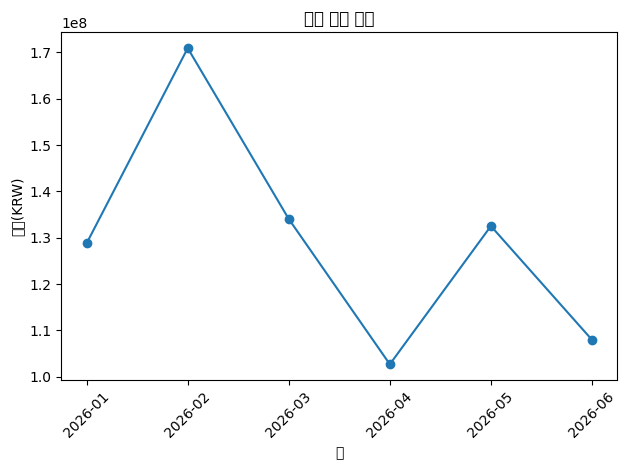

In [8]:
ax = monthly.plot(x='month', y='revenue', marker='o', legend=False)
ax.set_title('월별 매출 추이')
ax.set_xlabel('월')
ax.set_ylabel('매출(KRW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'monthly_revenue.png', dpi=150)
plt.show()

/tmp/ipykernel_881/3550499342.py:7: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/3550499342.py:7: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/3550499342.py:7: UserWarning: Glyph 44428 (\N{HANGUL SYLLABLE GWEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/3550499342.py:7: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/3550499342.py:7: UserWarning: Glyph 45224 (\N{HANGUL SYLLABLE NAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/3550499342.py:7: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_881/3550499342.py:7: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

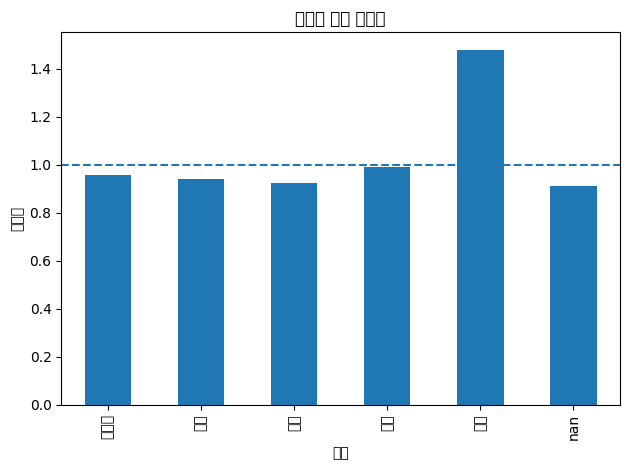

In [9]:
top_region = region.sort_values('revenue', ascending=False)
ax = top_region.plot(kind='bar', x='region', y='achievement_rate', legend=False)
ax.set_title('지역별 목표 달성률')
ax.set_xlabel('지역')
ax.set_ylabel('달성률')
plt.axhline(1.0, linestyle='--')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'region_achievement.png', dpi=150)
plt.show()

## 2-6. 검산

In [10]:
total_revenue = clean['revenue'].sum()
monthly_sum = monthly['revenue'].sum()
region_sum = region['revenue'].sum()
check = pd.DataFrame({
    'check_item':['raw_total','monthly_total','region_total'],
    'value':[total_revenue, monthly_sum, region_sum]
})
display(check)
assert abs(total_revenue - monthly_sum) < 1e-6
assert abs(total_revenue - region_sum) < 1e-6
print('검산 통과')

,check_item,value
0,raw_total,776971363.0
1,monthly_total,776971363.0
2,region_total,776971363.0


검산 통과


## 2-7. 보고서 초안 작성 과제
AI에게 월별·지역별 결과표와 차트를 바탕으로 다음 형식으로 보고서 초안을 작성하게 하세요.

1. 데이터로 확인된 사실
2. 데이터 기반 해석
3. 추가 데이터가 필요한 가설
4. 경영진용 3문장 요약

In [11]:
monthly.to_csv(OUTPUT_DIR/'monthly_kpi.csv', index=False, encoding='utf-8-sig')
region.to_csv(OUTPUT_DIR/'region_kpi.csv', index=False, encoding='utf-8-sig')
print('saved:', list(OUTPUT_DIR.glob('*')))

saved: [PosixPath('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/output/ad_weekday_earnings_compare.png'), PosixPath('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/output/ad_monthly_comparison.csv'), PosixPath('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/output/ad_daily_earnings_compare.png'), PosixPath('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/output/monthly_revenue.png'), PosixPath('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/output/region_achievement.png'), PosixPath('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/output/monthly_kpi.csv'), PosixPath('/content/drive/MyDrive/LGE-2026/llm_agent_training_package_v2/output/region_kpi.csv')]
